# Config

In [1]:
import numpy as np
import sys
import pandas as pd

In [2]:
Proj_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/FG_2026_Projections'

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers'

In [4]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [5]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

In [6]:
sys.path.append('../')

In [7]:
Latest_Proj = {
    'Hitter':'Jan23_2026',
    'Pitcher':'Jan23_2026'
}

In [8]:
SGP_Calc_date = 'Jan25_2026'

In [9]:
publish_Val_Update = {
    'Hitter':True,
    'Pitcher':True
}

In [10]:

Hitter_Projections_df = pd.read_csv(f"{Proj_path}/my_Hitter_Proj_{Latest_Proj['Hitter']}.csv")
Pitcher_Projections_df = pd.read_csv(f"{Proj_path}/my_Pitcher_Proj_{Latest_Proj['Pitcher']}.csv")
#Pitcher_Projections_df['K'] = Pitcher_Projections_df['SO']
Hitter_Projections_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Pitcher_Projections_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)


In [11]:
Pitcher_Projections_df[Pitcher_Projections_df['FG ID'].isin([key for key, val in Pitcher_Projections_df['FG ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,H,R,ER,HR,BB,HBP,SO,WAR,ADP,POS


In [12]:
Hitter_Projections_df = Hitter_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_Projections_df = Pitcher_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [13]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin([key for key, val in Hitter_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,R,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions


In [14]:
Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu ID'].isin([key for key, val in Pitcher_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,ER,HR,BB,HBP,SO,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions


<Axes: >

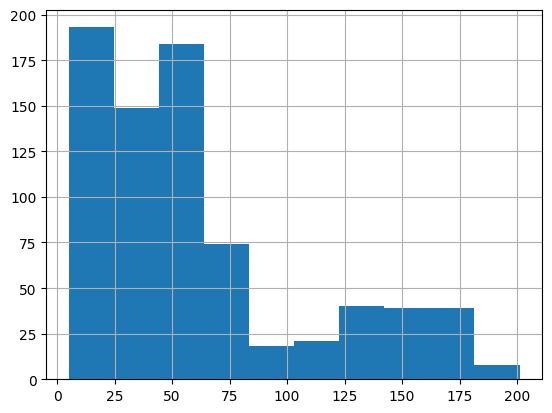

In [15]:
Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 5.]['IP'].hist()

In [16]:

#Filter Pitchers
Pitcher_Projections_df = Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 40.]

#Filter Hitters
Hitter_Projections_df = Hitter_Projections_df[Hitter_Projections_df['AB'] > 100.]

In [17]:
from Stat_modules import OBP,SLG,HR9,ERA,WHIP,TB
Hitter_Projections_df['OBP'] = OBP(Hitter_Projections_df['H'],Hitter_Projections_df['BB'],Hitter_Projections_df['HBP'],Hitter_Projections_df['SF'],Hitter_Projections_df['AB'])
Hitter_Projections_df['TB'] = TB(Hitter_Projections_df['1B'],Hitter_Projections_df['2B'],Hitter_Projections_df['3B'],Hitter_Projections_df['HR'])
Hitter_Projections_df['SLG'] = SLG(Hitter_Projections_df['TB'],Hitter_Projections_df['AB'])
Pitcher_Projections_df['HR9'] = HR9(Pitcher_Projections_df['HR'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['ERA'] = ERA(Pitcher_Projections_df['ER'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['WHIP'] = WHIP(Pitcher_Projections_df['BB'],Pitcher_Projections_df['H'],Pitcher_Projections_df['IP'])

In [18]:
#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}
Replacement_rank_stat = 'WAR'
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [19]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [20]:
Hitter_budget

2544.0

In [21]:
Player_id_cols = [
    'FG ID','Ottoneu ID','Name','NameASCII','Team','Ottoneu Positions'
]
Hitter_Count_Stats = [
    'G','PA','AB','H','1B','2B','3B','HR','R','RBI','BB','HBP','SF','WAR','ADP'
]
Pitcher_Count_Stats = [
    'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO','WAR','ADP'
]

In [22]:
import json
with open(League_path+'/SGP_Denom_dict.json','r') as f:
    SGP_Denom = json.load(f)

In [23]:
SGP_Denom['SO'] = SGP_Denom['K']

# Replacement Level & Playable Average Stats

C
1B
2B
SS
3B
OF
Util


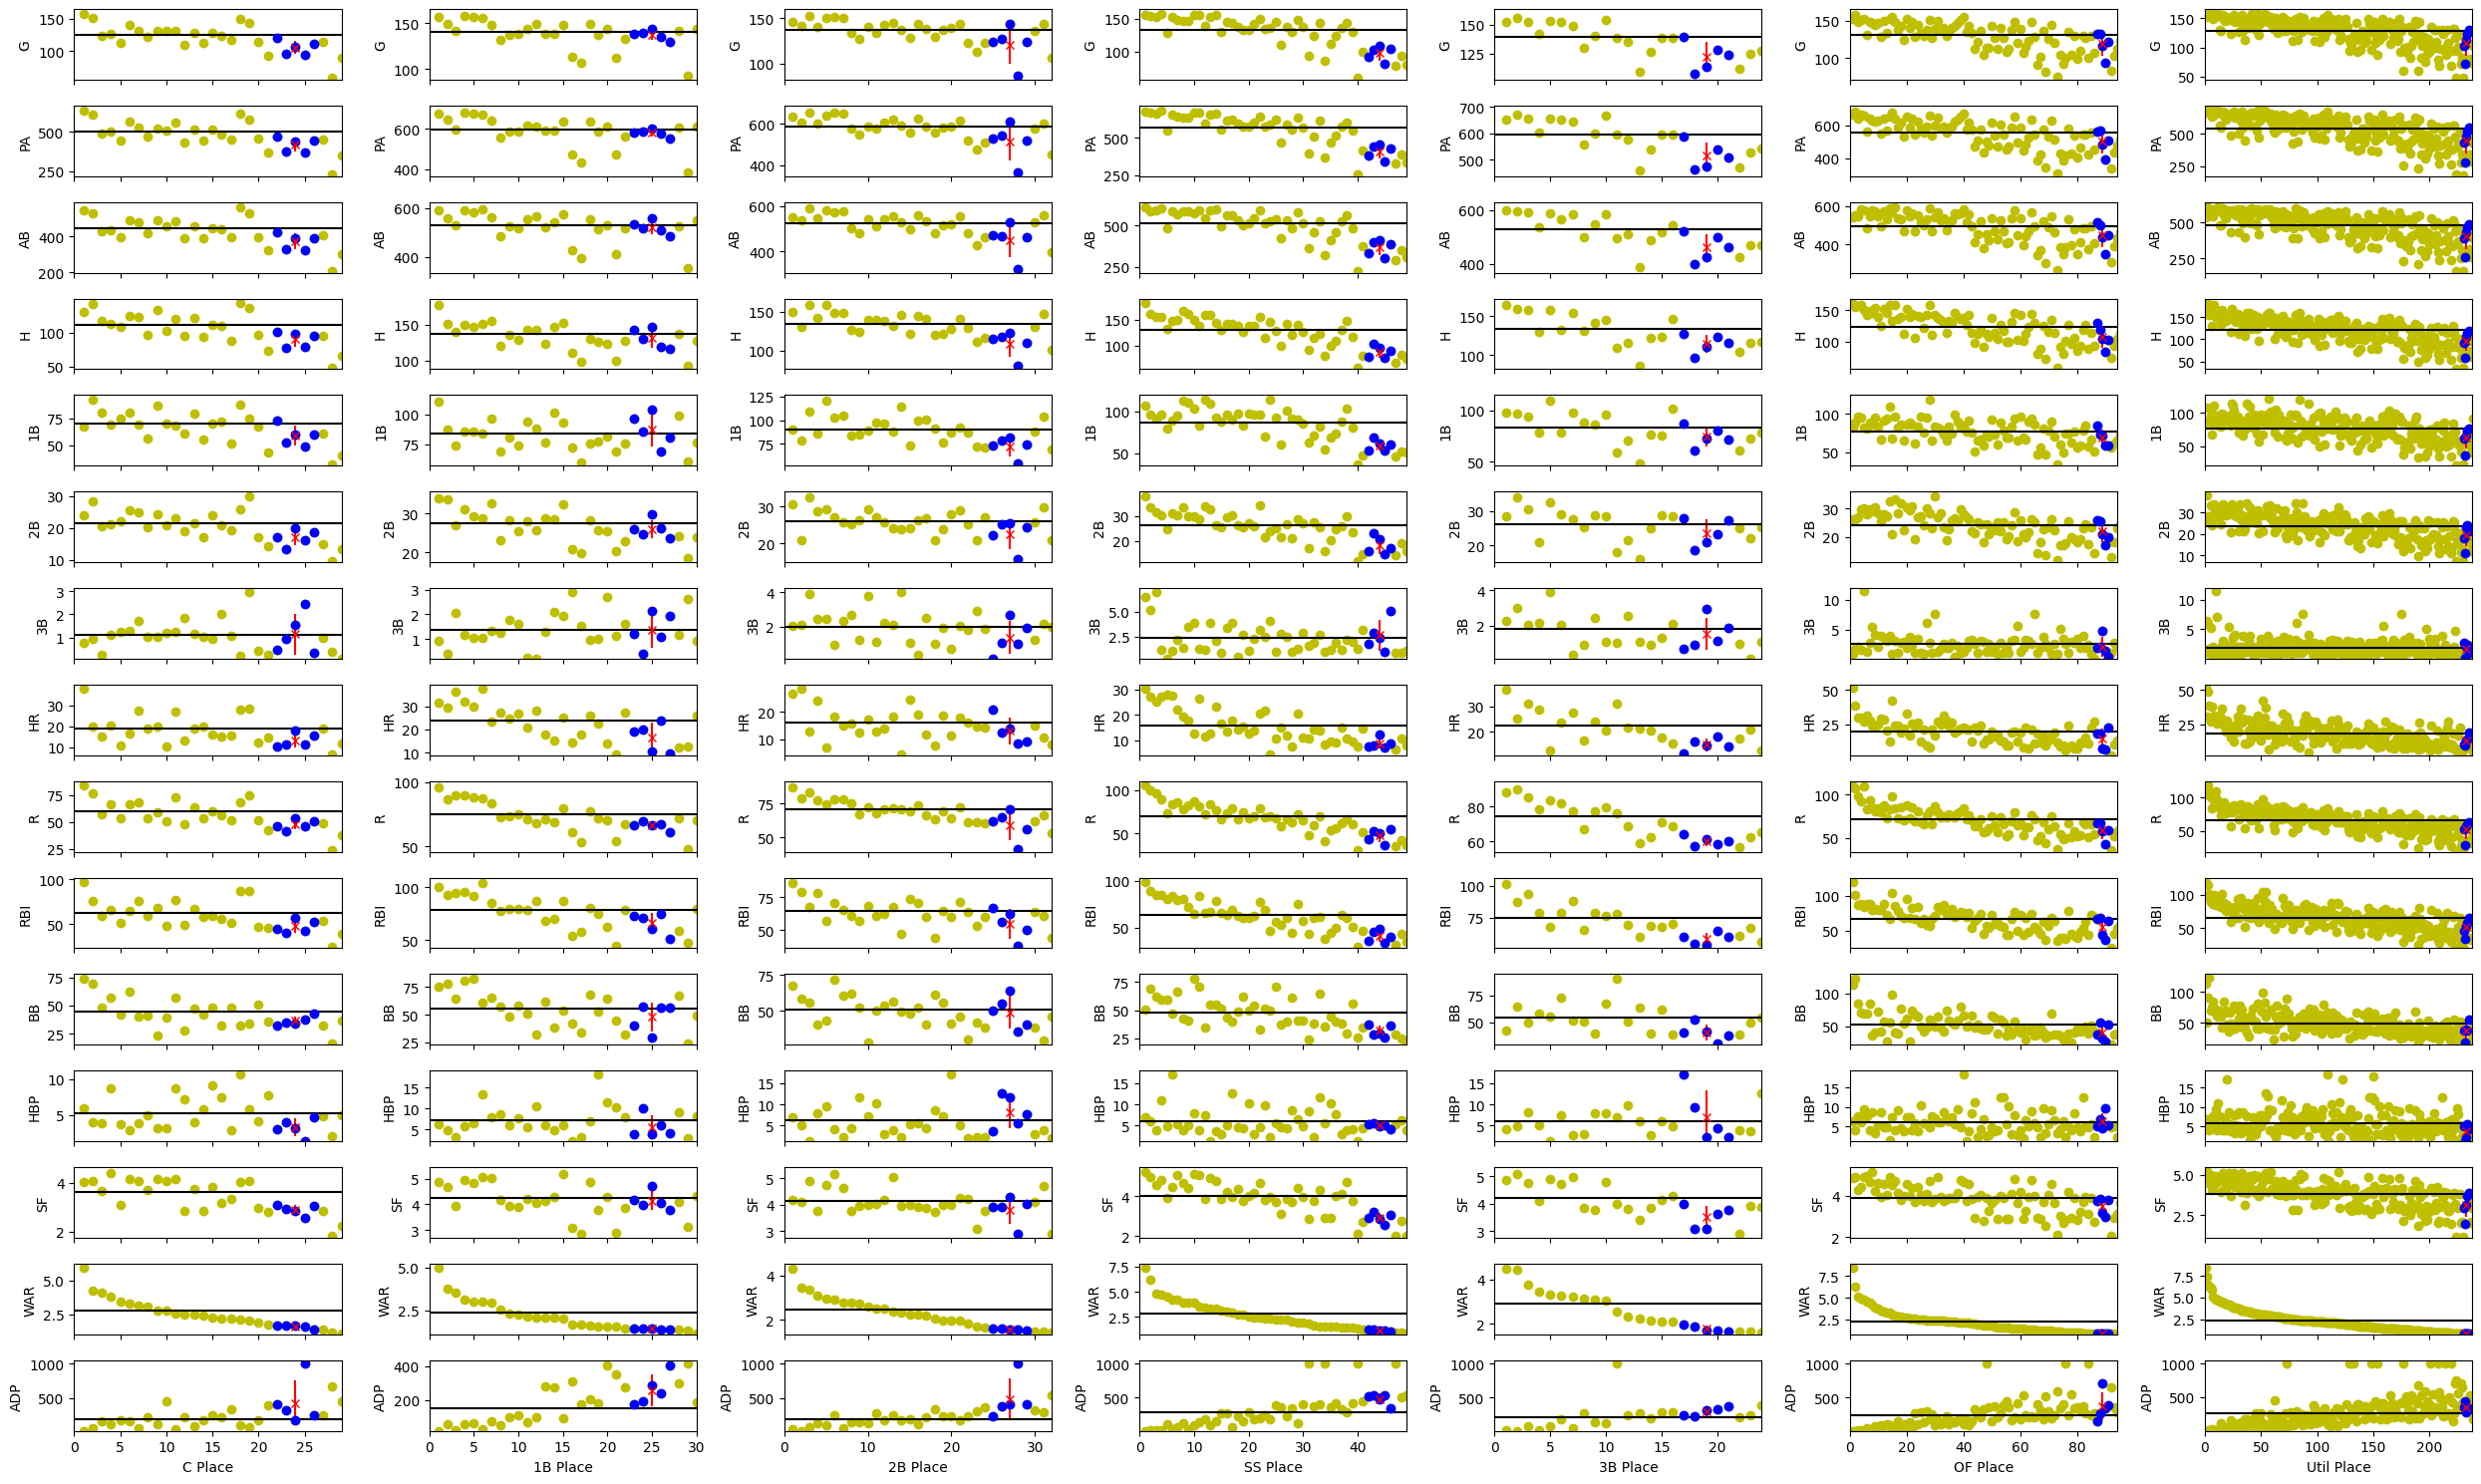

In [24]:
import matplotlib.pyplot as plt
import numpy as np

Hitting_Replacement_Stats_df = pd.DataFrame()
Hitting_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Hitter_Count_Stats),len(Hitting_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Pitching_Pos:
        continue
    This_Pos_df = Hitter_Projections_df[Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'Util':
        This_Pos_df = Hitter_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Hitter_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Hitting_Replacement_Stats_df = pd.concat([
            Hitting_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}_repl',
                'mean':mean
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Hitting_Average_Stats_df = pd.concat([
            Hitting_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}_avg',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [25]:
Hitting_Replacement_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G_repl,106.004187
0,C,PA_repl,417.758697
0,C,AB_repl,373.951600
0,C,H_repl,90.127703
0,C,1B_repl,58.741881
...,...,...,...
0,Util,BB_repl,37.420576
0,Util,HBP_repl,3.596710
0,Util,SF_repl,3.113955
0,Util,WAR_repl,0.838061


In [26]:
Hitting_Average_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G_avg,125.482192
0,C,PA_avg,500.189700
0,C,AB_avg,445.879628
0,C,H_avg,111.102315
0,C,1B_avg,69.787867
...,...,...,...
0,Util,BB_avg,48.703181
0,Util,HBP_avg,5.793058
0,Util,SF_avg,3.808248
0,Util,WAR_avg,2.296404


SP
RP
P


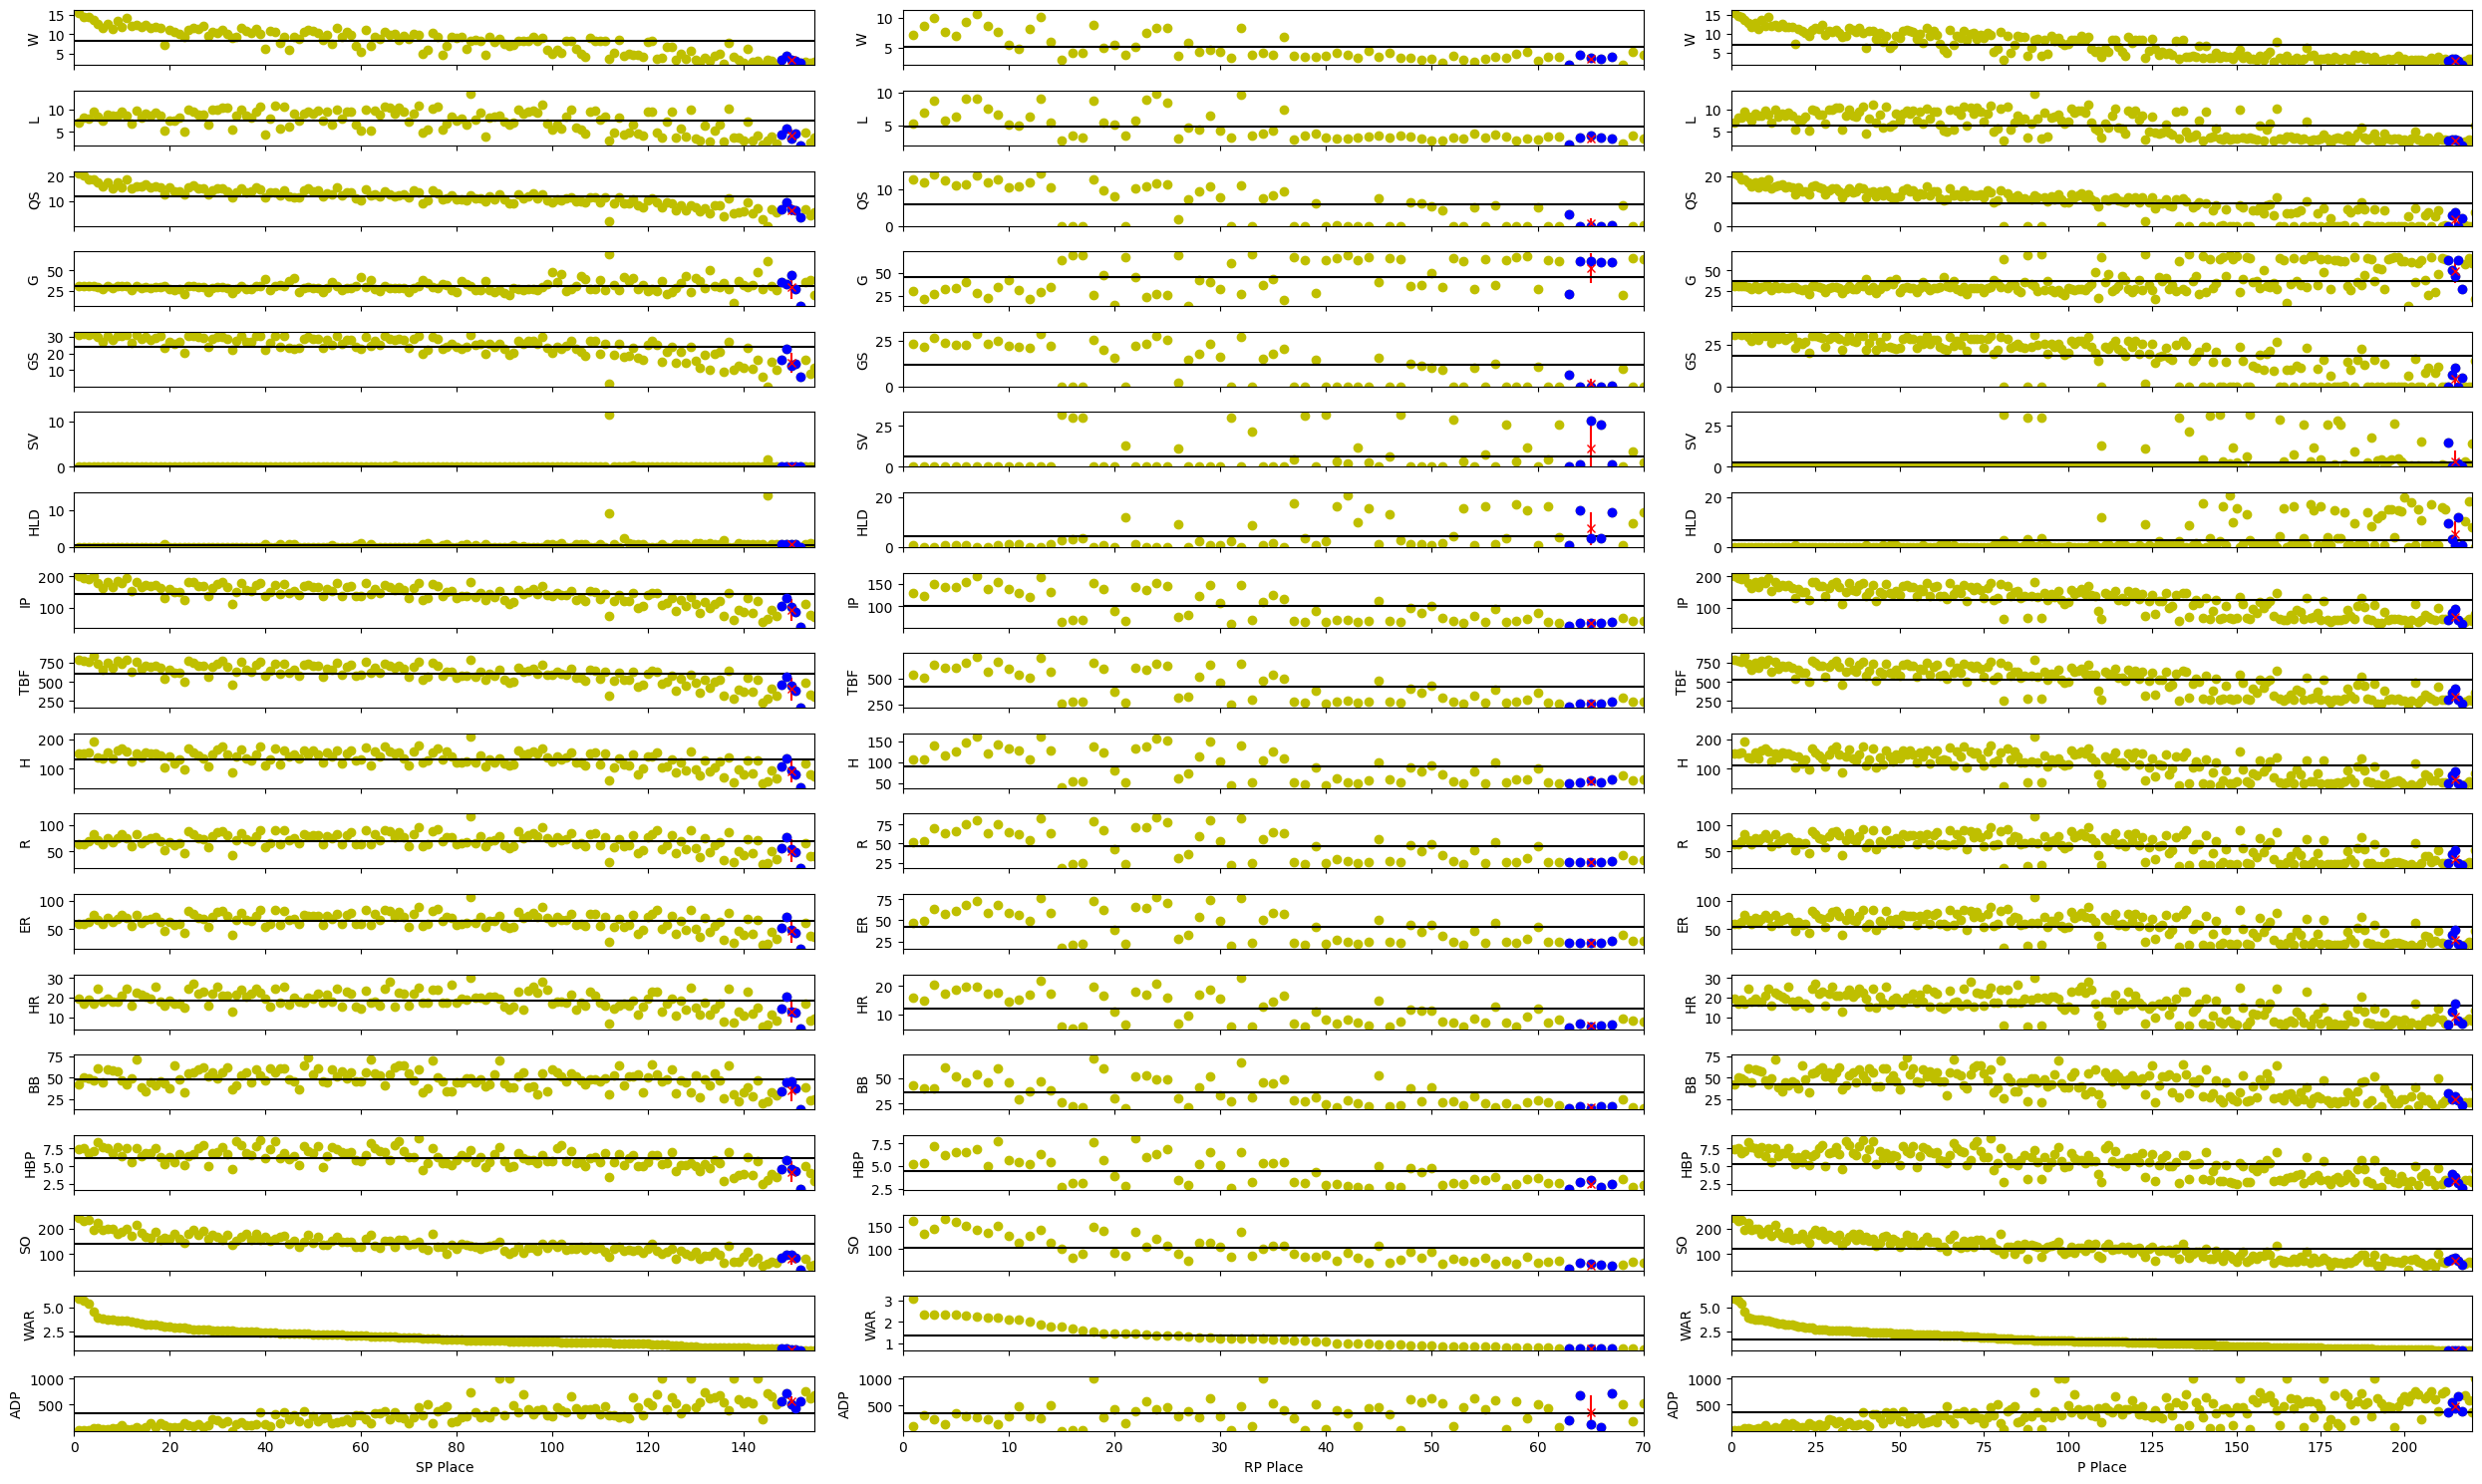

In [27]:
import matplotlib.pyplot as plt
import numpy as np

Pitching_Replacement_Stats_df = pd.DataFrame()
Pitching_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Pitcher_Count_Stats),len(Pitching_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Hitting_Pos:
        continue
    This_Pos_df = Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'P':
        This_Pos_df = Pitcher_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Pitcher_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Pitching_Replacement_Stats_df = pd.concat([
            Pitching_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}_repl',
                'mean':mean,
                'std':std
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Pitching_Average_Stats_df = pd.concat([
            Pitching_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}_avg',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [28]:
Pitching_Replacement_Stats_df.head()

,Ottoneu Positions,Stat,mean,std
0,SP,W_repl,3.432000,0.614464
0,SP,L_repl,4.056377,1.395234
0,SP,QS_repl,6.623811,2.038621
0,SP,G_repl,29.305294,14.263946
0,SP,GS_repl,14.307017,5.843768


# Calc Raw SGP

In [29]:
Rate_Scoring_Categories_Batting

['OBP', 'SLG']

In [30]:
Rate_Scoring_Categories_Pitching

['HR9', 'ERA', 'WHIP']

In [31]:
SGP_Denom

{'R': 25.28251748251743,
 'HR': 11.508403361344515,
 'OBP': 0.002503279720279701,
 'SLG': 0.00528697202797202,
 'K': 47.5227326545109,
 'HR9': -0.026016417074877514,
 'ERA': -0.08937283374192077,
 'WHIP': -0.017438135920127117,
 'SO': 47.5227326545109}

In [32]:
for stat in Count_Scoring_Categories_Batting:
    Hitter_Projections_df[f'{stat}_SGP_raw'] = Hitter_Projections_df[stat]/SGP_Denom[stat]

In [33]:
for stat in Count_Scoring_Categories_Pitching:
    Pitcher_Projections_df[f'{stat}_SGP_raw'] = Pitcher_Projections_df[stat]/SGP_Denom[stat]

In [34]:
Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

Stat,Ottoneu Positions,1B_repl,2B_repl,3B_repl,AB_repl,ADP_repl,BB_repl,G_repl,HBP_repl,HR_repl,H_repl,PA_repl,RBI_repl,R_repl,SF_repl,WAR_repl
0,1B,87.173193,26.000971,1.360319,519.953360,258.966003,47.924435,137.301784,5.631373,16.619441,131.273869,579.500131,65.856227,66.068338,4.144643,1.439118
1,2B,72.141536,22.636760,1.356350,450.258400,485.052002,48.972472,121.101872,8.226067,13.015070,108.909744,513.089280,54.598872,59.088808,3.807678,1.571938
2,3B,74.526048,23.578152,1.508494,460.779600,290.091995,40.904536,122.267200,7.084581,14.900736,114.873448,513.953120,58.293928,60.015544,3.511247,1.773587
3,C,58.741881,17.069879,1.140542,373.951600,427.456000,36.395623,106.004187,3.290218,13.209683,90.127703,417.758697,47.781141,47.665810,2.891496,1.614435
4,OF,69.291362,21.878405,2.100384,449.327029,366.812009,40.589686,119.119683,6.292464,14.670885,107.701014,501.951223,55.667511,58.636720,3.509524,0.876818
5,SS,59.516856,18.276536,2.641921,368.356960,476.712006,31.488432,97.798696,4.986702,8.730041,88.925328,409.416960,40.838176,47.607592,2.921678,1.190628
6,Util,62.471768,19.444472,1.682763,404.908800,351.101996,37.420576,107.958632,3.596710,13.558352,97.637360,450.275520,51.010592,52.057336,3.113955,0.838061


In [35]:
Hitting_Average_Stats_df.pivot_table('mean','Ottoneu Positions','Stat')

Stat,1B_avg,2B_avg,3B_avg,AB_avg,ADP_avg,BB_avg,G_avg,HBP_avg,HR_avg,H_avg,PA_avg,RBI_avg,R_avg,SF_avg,WAR_avg
Ottoneu Positions,,,,,,,,,,,,,,,
1B,84.029457,27.355614,1.347472,530.785866,151.398527,55.647849,140.736331,7.251582,23.800266,136.438177,598.770290,78.421723,74.837498,4.246443,2.352432
2B,90.317864,26.112584,2.000180,524.574530,196.090828,50.963244,137.704475,6.184112,16.004486,134.264868,587.680102,64.390395,71.032437,4.132058,2.453424
3B,83.746095,26.058423,1.798856,529.372872,199.900289,54.762271,139.063092,6.090565,22.261967,133.806908,595.395852,74.329005,74.225063,4.227543,2.926552
C,69.787867,21.552635,1.107421,445.879628,183.079194,44.446275,125.482192,5.320133,18.687977,111.102315,500.189700,62.698666,59.631303,3.610346,2.821792
OF,77.594839,24.249814,2.572120,492.755768,233.034735,52.153580,130.418696,5.955956,19.605051,123.987554,556.026844,66.913327,70.924983,3.889641,2.225144
SS,86.602356,26.240164,2.369042,511.054600,273.334812,47.814576,133.815535,5.951003,15.899285,131.044179,570.761215,63.641399,70.027989,4.035148,2.806819
Util,76.476358,23.684234,1.951848,479.435890,260.401752,48.703181,127.653252,5.793058,18.487258,120.548692,538.987262,64.558209,66.652619,3.808248,2.296404


In [36]:
rest_of_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']
full_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']

In [37]:
rest_of_roster_df['rest_of_roster_count'] = (Replacement_Level['Util']/Num_teams)-1.
full_roster_df['full_roster_count'] = (Replacement_Level['Util']/Num_teams)

In [38]:
rest_of_roster_df['rest_of_roster'] = rest_of_roster_df['rest_of_roster_count']*rest_of_roster_df['mean']
full_roster_df['full_roster'] = full_roster_df['full_roster_count']*full_roster_df['mean']

In [39]:
rest_of_roster_stats = rest_of_roster_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_stats = full_roster_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [40]:
rest_of_roster_stats['H_avg'].values[0]

np.float64(2220.105073436061)

In [41]:
full_roster_stats['H_avg'].values[0]

np.float64(2340.653765206345)

In [42]:
full_roster_OBP = OBP(
        full_roster_stats['H_avg'].values[0],
        full_roster_stats['BB_avg'].values[0],
        full_roster_stats['HBP_avg'].values[0],
        full_roster_stats['SF_avg'].values[0],
        full_roster_stats['AB_avg'].values[0]
    ) 

In [43]:
Hitter_Projections_df['OBP_SGP_raw'] = (
    OBP(
        (Hitter_Projections_df['H']+rest_of_roster_stats['H_avg'].values[0]),
        (Hitter_Projections_df['BB']+rest_of_roster_stats['BB_avg'].values[0]),
        (Hitter_Projections_df['HBP']+rest_of_roster_stats['HBP_avg'].values[0]),
        (Hitter_Projections_df['SF']+rest_of_roster_stats['SF_avg'].values[0]),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB_avg'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

In [44]:
rest_of_roster_TB = TB(
    rest_of_roster_stats['1B_avg'].values[0],
    rest_of_roster_stats['2B_avg'].values[0],
    rest_of_roster_stats['3B_avg'].values[0],
    rest_of_roster_stats['HR_avg'].values[0])
full_roster_TB = TB(
    full_roster_stats['1B_avg'].values[0],
    full_roster_stats['2B_avg'].values[0],
    full_roster_stats['3B_avg'].values[0],
    full_roster_stats['HR_avg'].values[0])
full_roster_SLG = SLG(full_roster_TB,full_roster_stats['AB_avg'].values[0])
Hitter_Projections_df['SLG_SGP_raw'] = (
    SLG(
        (Hitter_Projections_df['TB']+rest_of_roster_TB),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB_avg'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

In [45]:
Hitter_Projections_df['TOTAL_SGP_raw'] = Hitter_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Batting]].sum(axis=1)

In [46]:
Hitter_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,Ottoneu Positions,OBP,TB,SLG,Pos Place,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,TOTAL_SGP_raw
52,15640,592450,Aaron Judge,NYY,Aaron Judge,153.025200,662.062400,537.949600,160.618000,82.237120,...,OF,0.422946,342.627564,0.636914,1.0,4.347273,4.459256,2.439730,2.304311,13.550570
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.564800,675.760000,576.206000,164.762400,82.635640,...,Util/SP,0.384457,351.095000,0.609322,3.0,4.683078,4.219974,1.503829,2.138434,12.545314
178,20123,665742,Juan Soto,NYM,Juan Soto,157.975200,684.287600,552.705600,154.576000,88.319000,...,OF,0.411102,301.469260,0.545443,4.0,4.246365,3.374845,2.209824,1.344591,11.175626
144,19611,665489,Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.366000,676.026000,588.644400,176.887600,110.617600,...,1B,0.382989,306.908984,0.521383,8.0,3.792140,2.728834,1.465344,1.142129,9.128446
63,16478,656941,Kyle Schwarber,PHI,Kyle Schwarber,155.792571,675.800571,564.906857,132.357714,67.557886,...,OF,0.352581,282.116570,0.499404,52.0,3.858024,3.685540,0.689915,0.848862,9.082343
103,18401,660670,Ronald Acuña Jr.,ATL,Ronald Acuna Jr.,148.186000,642.174000,545.095200,156.012400,96.978760,...,OF,0.386985,277.488072,0.509064,7.0,3.878981,2.621778,1.494157,0.927060,8.921977
335,25764,677951,Bobby Witt Jr.,KCR,Bobby Witt Jr.,156.003600,674.313200,610.947200,182.213600,107.513200,...,SS,0.356083,324.242432,0.530721,2.0,4.165962,2.645945,0.777886,1.296906,8.886699
138,19556,670541,Yordan Alvarez,HOU,Yordan Alvarez,130.497143,562.494286,480.731429,142.412571,81.625143,...,OF,0.389693,267.197349,0.555814,13.0,3.292278,2.725606,1.377686,1.279828,8.675399
536,35110,701762,Nick Kurtz,ATH,Nick Kurtz,141.979200,598.812800,526.843600,139.304000,74.174000,...,1B,0.345695,278.817316,0.529222,32.0,3.546759,3.143063,0.459168,1.112464,8.261454
345,25878,682998,Corbin Carroll,ARI,Corbin Carroll,152.658800,659.492400,575.403200,150.470400,82.360360,...,OF,0.347877,283.375760,0.492482,10.0,4.346007,2.321410,0.557387,0.783573,8.008377


<Axes: >

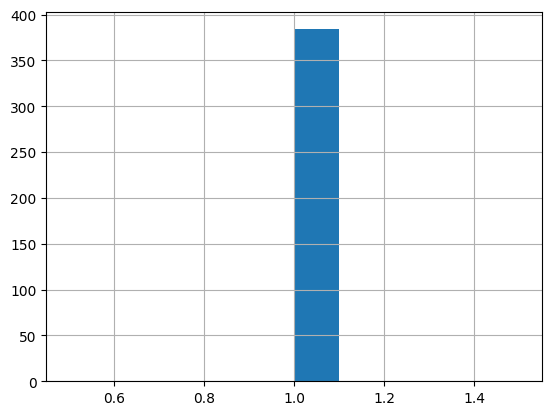

In [47]:
Hitter_Projections_df['FG ID'].value_counts().hist()

In [48]:
rest_of_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
full_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
rest_of_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
full_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
rest_of_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']
full_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']

In [49]:
rest_of_roster_SP_df['rest_of_roster_count'] = (Replacement_Level['SP']/Num_teams)-1.
full_roster_SP_df['full_roster_count'] = (Replacement_Level['SP']/Num_teams)
rest_of_roster_RP_df['rest_of_roster_count'] = (Replacement_Level['RP']/Num_teams)-1.
full_roster_RP_df['full_roster_count'] = (Replacement_Level['RP']/Num_teams)
rest_of_roster_P_df['rest_of_roster_count'] = (Replacement_Level['P']/Num_teams)-1.
full_roster_P_df['full_roster_count'] = (Replacement_Level['P']/Num_teams)

In [50]:
rest_of_roster_SP_df['rest_of_roster'] = rest_of_roster_SP_df['rest_of_roster_count']*rest_of_roster_SP_df['mean']
full_roster_SP_df['full_roster'] = full_roster_SP_df['full_roster_count']*full_roster_SP_df['mean']
rest_of_roster_RP_df['rest_of_roster'] = rest_of_roster_RP_df['rest_of_roster_count']*rest_of_roster_RP_df['mean']
full_roster_RP_df['full_roster'] = full_roster_RP_df['full_roster_count']*full_roster_RP_df['mean']
rest_of_roster_P_df['rest_of_roster'] = rest_of_roster_P_df['rest_of_roster_count']*rest_of_roster_P_df['mean']
full_roster_P_df['full_roster'] = full_roster_P_df['full_roster_count']*full_roster_P_df['mean']

In [51]:
rest_of_roster_SP_stats = rest_of_roster_SP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_SP_stats = full_roster_SP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_RP_stats = rest_of_roster_RP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_RP_stats = full_roster_RP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_P_stats = rest_of_roster_P_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_P_stats = full_roster_P_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [52]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts().reset_index()

,Ottoneu Positions,count
0,RP,237
1,SP,142
2,SP/RP,75
3,Util/SP,1


<Axes: xlabel='IP', ylabel='Count'>

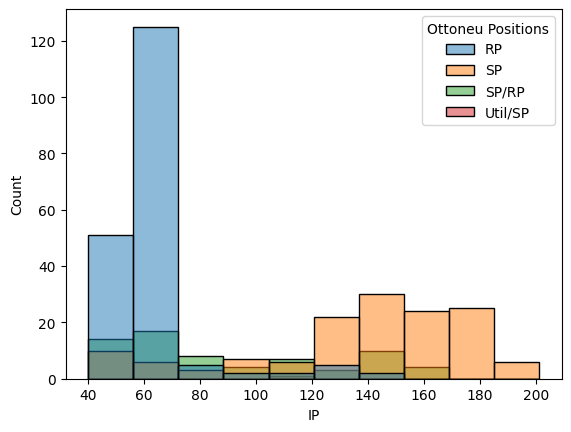

In [53]:
import seaborn as sns
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='IP',hue='Ottoneu Positions')

In [54]:
League_Avg_HR9 = HR9(
            full_roster_P_stats['HR_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0])

League_Avg_SP_HR9 = HR9(
            full_roster_SP_stats['HR_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0])

League_Avg_RP_HR9 = HR9(
            full_roster_RP_stats['HR_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])

League_Avg_ERA = ERA(
            full_roster_P_stats['ER_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0])

League_Avg_SP_ERA = ERA(
            full_roster_SP_stats['ER_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0])

League_Avg_RP_ERA = ERA(
            full_roster_RP_stats['ER_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])

League_Avg_WHIP = WHIP(
            full_roster_P_stats['BB_avg'].values[0],
            full_roster_P_stats['H_avg'].values[0],
            full_roster_P_stats['IP_avg'].values[0]
)

League_Avg_SP_WHIP = WHIP(
            full_roster_SP_stats['BB_avg'].values[0],
            full_roster_SP_stats['H_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]
)

League_Avg_RP_WHIP = WHIP(
            full_roster_RP_stats['BB_avg'].values[0],
            full_roster_RP_stats['H_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0]
)

# P League Average

In [55]:
print('HR9', League_Avg_HR9)
print('SP HR9', League_Avg_SP_HR9)
print('RP HR9', League_Avg_RP_HR9)
print('ERA', League_Avg_ERA)
print('SP ERA', League_Avg_SP_ERA)
print('RP ERA', League_Avg_RP_ERA)
print('WHIP', League_Avg_WHIP)
print('SP WHIP', League_Avg_SP_WHIP)
print('RP WHIP', League_Avg_RP_WHIP)

HR9 1.1495441960816457
SP HR9 1.1711610955882108
RP HR9 1.0781713513638667
ERA 3.9671699089818415
SP ERA 4.033598767832496
RP ERA 3.8292797624807857
WHIP 1.2573264924661367
SP WHIP 1.2638662715794247
RP WHIP 1.2561056462718603


In [56]:
Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<(Replacement_Level['P'])]

,FG ID,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,HR9,ERA,WHIP,Pos Place,SO_SGP_raw
2,10233,547973,Aroldis Chapman,BOS,Aroldis Chapman,3.355612,3.199640,0.000000,61.23632,0.000000,...,1.232904,46.840000,['RP'],5644,RP,0.849794,2.957060,1.161047,133.0,1.737819
3,10310,554430,Zack Wheeler,PHI,Zack Wheeler,9.304912,5.024288,12.691840,20.43608,20.436080,...,2.875334,148.449997,['SP'],15962,SP,1.077212,3.156823,1.073152,23.0,3.040254
6,10603,519242,Chris Sale,ATL,Chris Sale,11.719560,7.419640,15.904440,27.12540,27.125400,...,3.827484,34.709999,['SP'],14393,SP,1.002222,3.233025,1.101263,6.0,4.119805
8,11156,518876,Merrill Kelly,ARI,Merrill Kelly,11.074600,10.016672,14.957760,30.01280,30.012800,...,2.069470,229.899994,['SP'],17763,SP,1.180407,4.176735,1.278588,65.0,3.350304
10,11486,592662,Robbie Ray,SFG,Robbie Ray,10.346536,10.127720,14.337400,29.97904,29.979040,...,1.789644,155.520004,['SP'],14941,SP,1.242702,4.175621,1.297106,80.0,3.797938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734,7048,518585,Fernando Cruz,NYY,Fernando Cruz,3.067644,3.372504,0.000000,60.98620,0.067879,...,0.600128,677.710022,['RP'],8550,RP,1.069649,3.510556,1.226384,202.0,1.662923
736,9132,543135,Nathan Eovaldi,TEX,Nathan Eovaldi,11.650400,8.553660,15.664440,27.84448,27.844480,...,3.204434,146.449997,['SP'],9335,SP,1.033185,3.613511,1.154089,16.0,3.404367
1654,sa3020707,702281,Robby Snelling,MIA,Robby Snelling,7.029260,6.722076,9.363644,19.29048,19.290480,...,1.520722,999.000000,['SP'],42741,SP,1.096627,4.153501,1.323766,99.0,2.127589
2142,sa3023268,806258,Thomas White,MIA,Thomas White,4.215084,3.773152,5.235620,10.27906,10.279060,...,0.843555,999.000000,['SP'],44487,SP,1.067980,3.886331,1.385957,165.0,1.457488


<Axes: >

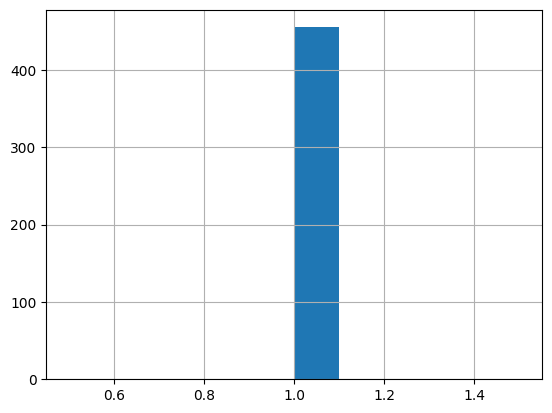

In [57]:
Pitcher_Projections_df['Pos Place'].value_counts().hist()

<Axes: xlabel='Pos Place', ylabel='Pos Place'>

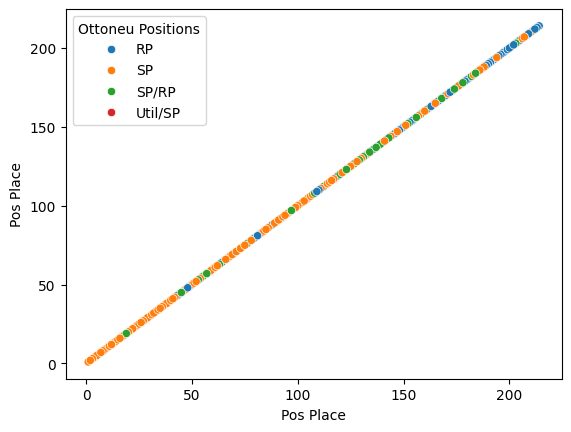

In [58]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='Pos Place',y='Pos Place',hue='Ottoneu Positions')

<Axes: xlabel='ERA', ylabel='Count'>

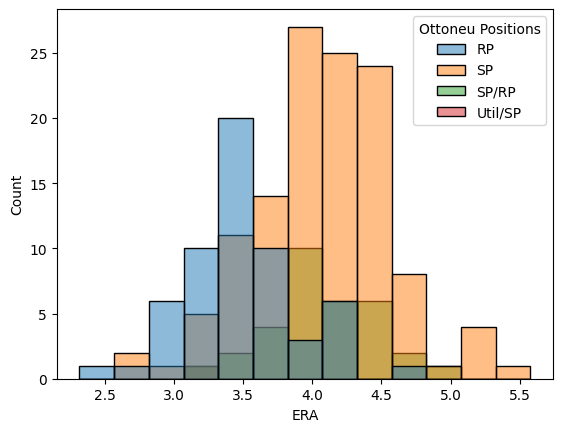

In [59]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='ERA',hue='Ottoneu Positions')

<Axes: xlabel='IP', ylabel='Count'>

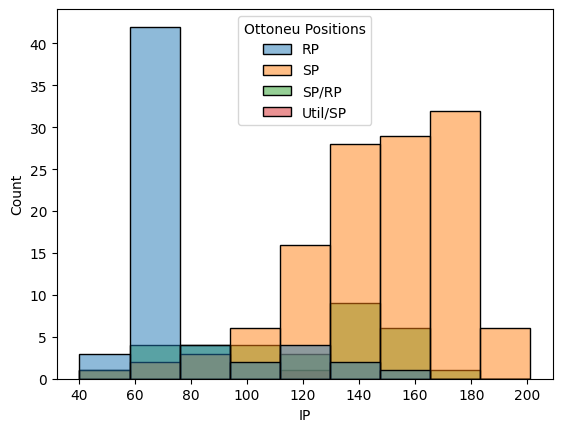

In [60]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='IP',hue='Ottoneu Positions')

In [61]:
Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))

0       False
1       False
2       False
3        True
6        True
        ...  
2095     True
2142     True
2175     True
2529    False
2746     True
Name: Ottoneu Positions, Length: 455, dtype: bool

In [62]:
Pitcher_Projections_df['HR9_SGP_raw'] = (
    HR9(
        (Pitcher_Projections_df['HR'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['HR_avg'].values[0],
            rest_of_roster_RP_stats['HR_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_HR9,
        League_Avg_RP_HR9
    )
) / SGP_Denom['HR9']

In [63]:
Pitcher_Projections_df['ERA_SGP_raw'] = (
    ERA(
        (Pitcher_Projections_df['ER'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['ER_avg'].values[0],
            rest_of_roster_RP_stats['ER_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_ERA,
        League_Avg_RP_ERA
    )
) / SGP_Denom['ERA']

In [64]:
Pitcher_Projections_df['WHIP_SGP_raw'] = (
    WHIP(
        (Pitcher_Projections_df['BB'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['BB_avg'].values[0],
            rest_of_roster_RP_stats['BB_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['H'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['H_avg'].values[0],
            rest_of_roster_RP_stats['H_avg'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP_avg'].values[0],
            rest_of_roster_RP_stats['IP_avg'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_WHIP,
        League_Avg_RP_WHIP
    )
) / SGP_Denom['WHIP']

In [65]:
Pitcher_Projections_df['TOTAL_SGP_raw'] = Pitcher_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Pitching]].sum(axis=1)

In [66]:
Pitcher_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,MLBAMID,Name,Team,NameASCII,W,L,QS,G,GS,...,Ottoneu Positions,HR9,ERA,WHIP,Pos Place,SO_SGP_raw,HR9_SGP_raw,ERA_SGP_raw,WHIP_SGP_raw,TOTAL_SGP_raw
344,22267,669373,Tarik Skubal,DET,Tarik Skubal,15.349680,7.016644,21.063400,31.15064,31.15064,...,SP,0.882934,2.687728,0.987149,1.0,5.047605,1.188209,1.615113,1.701927,9.552854
714,33677,694973,Paul Skenes,PIT,Paul Skenes,14.546840,8.081052,20.244960,31.28424,31.28424,...,SP,0.790954,2.767541,1.051617,2.0,4.880216,1.528918,1.482036,1.273374,9.164544
521,27463,676979,Garrett Crochet,BOS,Garrett Crochet,14.298760,8.058244,18.816000,30.92356,30.92356,...,SP,0.904065,3.008174,1.074135,3.0,4.891730,1.058912,1.183417,1.122220,8.256280
683,31757,695243,Mason Miller,SDP,Mason Miller,3.076936,2.781668,0.021111,64.23908,0.02887,...,RP,0.806302,2.315414,0.993832,81.0,2.113607,1.349535,2.187529,1.942349,7.593021
146,17995,657277,Logan Webb,SFG,Logan Webb,13.585360,9.458360,18.867920,31.32116,31.32116,...,SP,0.765265,3.392781,1.189805,4.0,4.071382,1.689861,0.776628,0.460017,6.997887
284,21029,661395,Jhoan Duran,PHI,Jhoan Duran,4.204012,3.459152,0.000000,69.25068,0.00000,...,RP,0.659828,2.709456,1.110158,88.0,1.716289,2.164547,1.686653,1.126623,6.694111
655,30279,693433,Bryan Woo,SEA,Bryan Woo,14.292640,8.666328,18.715160,31.01756,31.01756,...,SP,1.150858,3.224773,1.046878,11.0,4.214168,0.081516,0.945330,1.299781,6.540795
573,27867,671922,Cade Smith,CLE,Cade Smith,4.217688,3.237512,0.000000,69.89816,0.00000,...,RP,0.762575,2.886981,1.072864,92.0,1.870485,1.651732,1.435617,1.430806,6.388640
6,10603,519242,Chris Sale,ATL,Chris Sale,11.719560,7.419640,15.904440,27.12540,27.12540,...,SP,1.002222,3.233025,1.101263,6.0,4.119805,0.582476,0.803508,0.836417,6.342206
42,13743,608331,Max Fried,NYY,Max Fried,13.497880,8.656616,17.732800,30.20236,30.20236,...,SP,0.881906,3.331856,1.184637,9.0,3.777577,1.119198,0.790399,0.457361,6.144534


<Axes: >

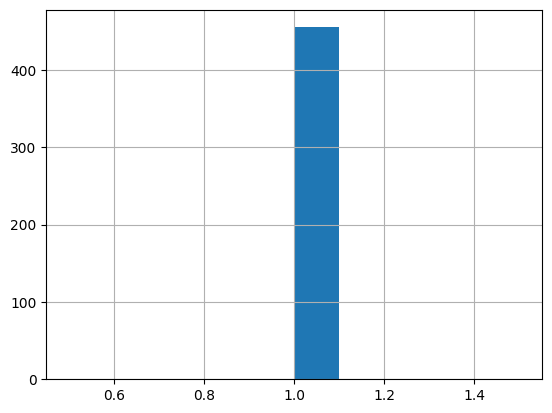

In [67]:
Pitcher_Projections_df['FG ID'].value_counts().hist()

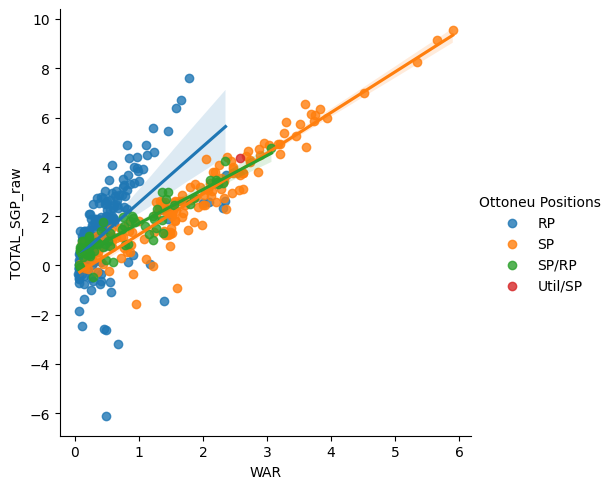

In [68]:
sns.lmplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='WAR',y='TOTAL_SGP_raw',hue='Ottoneu Positions')

# Replacement Level SGP

In [69]:
Hitting_Replacement_pivot_df = Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [70]:
Hitting_Replacement_pivot_df

Stat,Ottoneu Positions,1B_repl,2B_repl,3B_repl,AB_repl,ADP_repl,BB_repl,G_repl,HBP_repl,HR_repl,H_repl,PA_repl,RBI_repl,R_repl,SF_repl,WAR_repl
0,1B,87.173193,26.000971,1.360319,519.953360,258.966003,47.924435,137.301784,5.631373,16.619441,131.273869,579.500131,65.856227,66.068338,4.144643,1.439118
1,2B,72.141536,22.636760,1.356350,450.258400,485.052002,48.972472,121.101872,8.226067,13.015070,108.909744,513.089280,54.598872,59.088808,3.807678,1.571938
2,3B,74.526048,23.578152,1.508494,460.779600,290.091995,40.904536,122.267200,7.084581,14.900736,114.873448,513.953120,58.293928,60.015544,3.511247,1.773587
3,C,58.741881,17.069879,1.140542,373.951600,427.456000,36.395623,106.004187,3.290218,13.209683,90.127703,417.758697,47.781141,47.665810,2.891496,1.614435
4,OF,69.291362,21.878405,2.100384,449.327029,366.812009,40.589686,119.119683,6.292464,14.670885,107.701014,501.951223,55.667511,58.636720,3.509524,0.876818
5,SS,59.516856,18.276536,2.641921,368.356960,476.712006,31.488432,97.798696,4.986702,8.730041,88.925328,409.416960,40.838176,47.607592,2.921678,1.190628
6,Util,62.471768,19.444472,1.682763,404.908800,351.101996,37.420576,107.958632,3.596710,13.558352,97.637360,450.275520,51.010592,52.057336,3.113955,0.838061


In [71]:
Hitting_Replacement_SGP_df = pd.DataFrame()
for pos in Hitting_Pos:
    this_pos_repl_df = Hitting_Replacement_pivot_df[Hitting_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Batting:
        Repl_mean = this_pos_repl_df[f'{stat}_repl'].values[0]

        This_pos_dict[f'{stat}_SGP'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP']

    This_pos_dict['OBP_SGP'] = (OBP(
        (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_stats['H_avg'].values[0]),
        (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_stats['BB_avg'].values[0]),
        (this_pos_repl_df['HBP_repl'].values[0]+rest_of_roster_stats['HBP_avg'].values[0]),
        (this_pos_repl_df['SF_repl'].values[0]+rest_of_roster_stats['SF_avg'].values[0]),
        (this_pos_repl_df['AB_repl'].values[0]+rest_of_roster_stats['AB_avg'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

    quick_running_sum += This_pos_dict['OBP_SGP']
    
    repl_level_TB = TB(
    this_pos_repl_df['1B_repl'].values[0],
    this_pos_repl_df['2B_repl'].values[0],
    this_pos_repl_df['3B_repl'].values[0],
    this_pos_repl_df['HR_repl'].values[0])

    This_pos_dict['SLG_SGP'] = (
    SLG(
        (repl_level_TB+rest_of_roster_TB),
        (this_pos_repl_df['AB_repl'].values[0]+rest_of_roster_stats['AB_avg'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

    quick_running_sum += This_pos_dict['SLG_SGP']

    This_pos_dict['Total_SGP'] = quick_running_sum

    Hitting_Replacement_SGP_df = pd.concat([
        Hitting_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [72]:
Hitting_Replacement_SGP_df

,Ottoneu Positions,R_SGP,HR_SGP,OBP_SGP,SLG_SGP,Total_SGP
0,C,1.885327,1.147829,-0.223535,-0.199366,2.610255
0,1B,2.613202,1.444113,-0.122265,-0.225084,3.709967
0,2B,2.337141,1.130919,-0.012208,-0.360996,3.094856
0,SS,1.883024,0.758580,-0.284031,-0.360907,1.996666
0,3B,2.373796,1.294770,-0.149368,-0.201841,3.317358
0,OF,2.319260,1.274798,-0.310460,-0.261474,3.022123
0,Util,2.059025,1.178126,-0.290048,-0.232478,2.714625


In [73]:
Hitting_Replacement_SGP_df = Hitting_Replacement_SGP_df.set_index('Ottoneu Positions')

In [74]:
Hitting_Replacement_SGP_df

,R_SGP,HR_SGP,OBP_SGP,SLG_SGP,Total_SGP
Ottoneu Positions,,,,,
C,1.885327,1.147829,-0.223535,-0.199366,2.610255
1B,2.613202,1.444113,-0.122265,-0.225084,3.709967
2B,2.337141,1.130919,-0.012208,-0.360996,3.094856
SS,1.883024,0.758580,-0.284031,-0.360907,1.996666
3B,2.373796,1.294770,-0.149368,-0.201841,3.317358
OF,2.319260,1.274798,-0.310460,-0.261474,3.022123
Util,2.059025,1.178126,-0.290048,-0.232478,2.714625


In [75]:
Hitting_Replacement_SGP_df.loc['C']

R_SGP        1.885327
HR_SGP       1.147829
OBP_SGP     -0.223535
SLG_SGP     -0.199366
Total_SGP    2.610255
Name: C, dtype: float64

In [76]:
pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['R_SGP']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['Total_SGP'].idxmin())).to_list(),index=Hitter_Projections_df.index)

,0,1
1,2.319260,OF
2,2.319260,OF
3,2.319260,OF
4,2.373796,3B
5,2.613202,1B
...,...,...
1568,2.319260,OF
1625,2.319260,OF
1720,2.319260,OF
1775,2.373796,3B


In [77]:
for stat in Scoring_Categories_Batting:
    Hitter_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['Total_SGP'].idxmin())).to_list(),index=Hitter_Projections_df.index)
    Hitter_Projections_df[f'{stat}_SGP_norm'] = Hitter_Projections_df[f'{stat}_SGP_raw'] - Hitter_Projections_df[f'{stat}_SGP_repl']

In [78]:
Hitter_Projections_df.head()

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,TOTAL_SGP_raw,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm
1,10155,545361,Mike Trout,LAA,Mike Trout,129.1444,556.3820,472.4704,113.9432,65.56196,...,6.163034,2.319260,OF,0.594240,1.274798,1.110691,-0.310460,0.799201,-0.261474,0.636780
2,10815,595777,Jurickson Profar,ATL,Jurickson Profar,144.9268,627.0208,543.6880,134.1240,90.24152,...,4.363410,2.319260,OF,0.643398,1.274798,0.180810,-0.310460,0.627702,-0.261474,-0.110623
3,11477,592885,Christian Yelich,MIL,Christian Yelich,142.5496,612.5212,536.5336,137.0560,92.19288,...,4.912761,2.319260,OF,0.656840,1.274798,0.437218,-0.310460,0.667244,-0.261474,0.129336
4,11493,592518,Manny Machado,SDP,Manny Machado,148.4948,643.5320,583.9552,153.9600,97.82496,...,5.730460,2.373796,3B,0.679889,1.294770,1.096130,-0.149368,0.108884,-0.201841,0.528199
5,11579,547180,Bryce Harper,PHI,Bryce Harper,149.4068,644.4472,556.8308,150.4592,87.70540,...,7.593168,2.613202,1B,0.805571,1.444113,1.100577,-0.122265,1.009677,-0.225084,0.967376


In [79]:
Hitter_Projections_df.groupby('Repl_Pos')['Ottoneu Positions'].value_counts()

Repl_Pos  Ottoneu Positions
1B        1B                    26
2B        2B                    15
          2B/3B                 11
          1B/2B                  3
          1B/2B/3B               2
3B        3B                    24
          1B/3B                  5
C         C                     51
          C/1B                   5
OF        OF                   135
          1B/OF                 10
          2B/OF                  7
          2B/3B/OF               6
          3B/OF                  3
          1B/2B/OF               3
          1B/3B/OF               1
          1B/OF/RP               1
SS        SS                    27
          2B/SS                 14
          2B/SS/3B               8
          1B/2B/SS/3B            6
          2B/SS/3B/OF            3
          2B/SS/OF               3
          SS/3B/OF               2
          SS/3B                  2
          1B/SS/3B/OF            1
          SS/OF                  1
          1B/2B/SS/3B/OF   

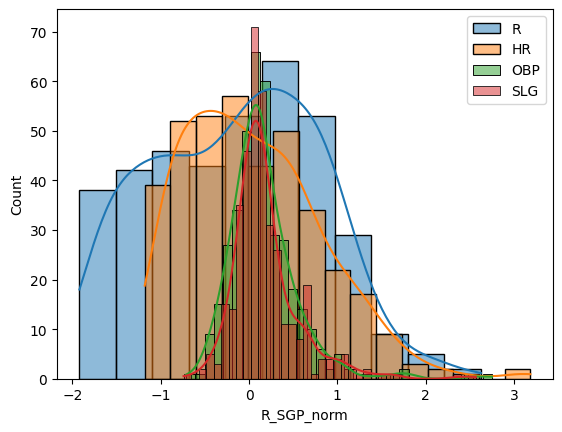

In [80]:
for stat in Scoring_Categories_Batting:
    sns.histplot(Hitter_Projections_df,x=f'{stat}_SGP_norm',label=stat,kde=True)
    #Hitter_Projections_df[f'{stat}_SGP_norm'].hist(label=stat)
plt.legend()

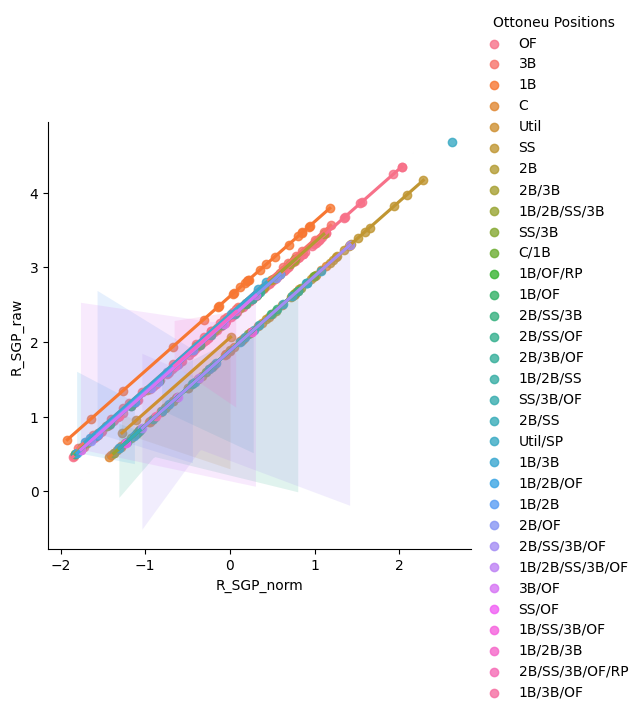

In [81]:
sns.lmplot(Hitter_Projections_df[Hitter_Projections_df['WAR']>0.05],x='R_SGP_norm',y='R_SGP_raw',hue='Ottoneu Positions')

In [82]:
Pitching_Replacement_pivot_df = Pitching_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [83]:
Pitching_Replacement_pivot_df

Stat,Ottoneu Positions,ADP_repl,BB_repl,ER_repl,GS_repl,G_repl,HBP_repl,HLD_repl,HR_repl,H_repl,IP_repl,L_repl,QS_repl,R_repl,SO_repl,SV_repl,TBF_repl,WAR_repl,W_repl
0,P,469.134009,25.214952,32.133272,4.673381,49.499504,2.953625,5.227670,10.282493,63.841960,71.946376,2.734706,2.621640,35.057888,73.770392,3.456142,303.52024,0.547137,2.749810
1,RP,375.078009,21.661048,23.832608,1.345233,55.359528,2.974755,7.379838,6.089578,53.522040,61.468672,3.060854,0.657762,25.925880,64.018088,11.388627,258.19904,0.753751,3.184328
2,SP,557.124011,35.270144,46.698728,14.307017,29.305294,4.240320,0.710842,12.996094,91.390816,93.955024,4.056377,6.623811,51.103848,81.340696,0.000000,404.35480,0.673705,3.432000


In [84]:
Pitching_Replacement_SGP_df = pd.DataFrame()
for pos in Pitching_Pos:
    this_pos_repl_df = Pitching_Replacement_pivot_df[Pitching_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Pitching:
        Repl_mean = this_pos_repl_df[f'{stat}_repl'].values[0]

        This_pos_dict[f'{stat}_SGP'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP']

    This_pos_dict['HR9_SGP'] = (
    HR9(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['HR_repl'].values[0]+rest_of_roster_SP_stats['HR_avg'].values[0]),
            (this_pos_repl_df['HR_repl'].values[0]+rest_of_roster_RP_stats['HR_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        HR9(
            full_roster_SP_stats['HR_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        HR9(
            full_roster_RP_stats['HR_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['HR9']

    quick_running_sum += This_pos_dict['HR9_SGP']

    This_pos_dict['ERA_SGP'] = (
    ERA(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['ER_repl'].values[0]+rest_of_roster_SP_stats['ER_avg'].values[0]),
            (this_pos_repl_df['ER_repl'].values[0]+rest_of_roster_RP_stats['ER_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        ERA(
            full_roster_SP_stats['ER_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        ERA(
            full_roster_RP_stats['ER_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['ERA']

    quick_running_sum += This_pos_dict['ERA_SGP']

    This_pos_dict['WHIP_SGP'] = (
    WHIP(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_SP_stats['BB_avg'].values[0]),
            (this_pos_repl_df['BB_repl'].values[0]+rest_of_roster_RP_stats['BB_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_SP_stats['H_avg'].values[0]),
            (this_pos_repl_df['H_repl'].values[0]+rest_of_roster_RP_stats['H_avg'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_SP_stats['IP_avg'].values[0]),
            (this_pos_repl_df['IP_repl'].values[0]+rest_of_roster_RP_stats['IP_avg'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        WHIP(
            full_roster_SP_stats['BB_avg'].values[0],
            full_roster_SP_stats['H_avg'].values[0],
            full_roster_SP_stats['IP_avg'].values[0]),
        WHIP(
            full_roster_RP_stats['BB_avg'].values[0],
            full_roster_RP_stats['H_avg'].values[0],
            full_roster_RP_stats['IP_avg'].values[0])     
    ) ) / SGP_Denom['WHIP']

    quick_running_sum += This_pos_dict['WHIP_SGP']

    This_pos_dict['Total_SGP'] = quick_running_sum

    Pitching_Replacement_SGP_df = pd.concat([
        Pitching_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [85]:
Pitching_Replacement_SGP_df

,Ottoneu Positions,SO_SGP,HR9_SGP,ERA_SGP,WHIP_SGP,Total_SGP
0,SP,1.711617,-0.152214,-0.264204,-0.259411,1.035787
0,RP,1.347105,0.872141,0.462423,0.230114,2.911783
0,P,1.552318,-1.115531,-0.297071,0.146214,0.285930


In [86]:
Pitching_Replacement_SGP_df = Pitching_Replacement_SGP_df.set_index('Ottoneu Positions')

In [88]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts()

Ottoneu Positions
RP         237
SP         142
SP/RP       75
Util/SP      1
Name: count, dtype: int64

In [91]:
for stat in Scoring_Categories_Pitching:
    Pitcher_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP']),Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))]['Total_SGP'].idxmin())).to_list(),index=Pitcher_Projections_df.index)
    Pitcher_Projections_df[f'{stat}_SGP_norm'] = Pitcher_Projections_df[f'{stat}_SGP_raw'] - Pitcher_Projections_df[f'{stat}_SGP_repl']

In [92]:
Pitcher_Projections_df['TOTAL_SGP'] = Pitcher_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Pitching]].sum(axis=1)
Hitter_Projections_df['TOTAL_SGP'] = Hitter_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Batting]].sum(axis=1)

In [93]:
Hitter_Projections_df.sort_values(['TOTAL_SGP'])

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm,TOTAL_SGP
443,29524,669326,Bryce Teodosio,LAA,Bryce Teodosio,52.999960,214.982800,196.863600,41.542520,28.645400,...,2.319260,OF,-1.423999,1.274798,-1.015473,-0.310460,-0.209309,-0.261474,-0.186994,-2.835774
81,17620,664702,Myles Straw,TOR,Myles Straw,33.297560,132.095600,119.174000,27.766000,20.775920,...,2.319260,OF,-1.755914,1.274798,-1.180610,-0.310460,0.160861,-0.261474,-0.009036,-2.784699
196,20538,669304,Jose Miranda,SDP,Jose Miranda,32.983480,139.387600,128.034000,31.377560,20.928720,...,2.373796,3B,-1.792134,1.294770,-1.013024,-0.149368,-0.011042,-0.201841,0.049595,-2.766606
494,31490,685133,Wade Meckler,LAA,Wade Meckler,27.613520,114.216800,102.113640,25.210280,18.558080,...,2.319260,OF,-1.857584,1.274798,-1.177648,-0.310460,0.261143,-0.261474,0.042555,-2.731535
102,18373,663624,Ryan Mountcastle,BAL,Ryan Mountcastle,36.729840,155.120000,142.432400,36.491160,23.897520,...,2.613202,1B,-1.919567,1.444113,-0.990960,-0.122265,0.003546,-0.225084,0.206358,-2.700624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,16478,656941,Kyle Schwarber,PHI,Kyle Schwarber,155.792571,675.800571,564.906857,132.357714,67.557886,...,2.319260,OF,1.538765,1.274798,2.410743,-0.310460,1.000376,-0.261474,1.110336,6.060220
335,25764,677951,Bobby Witt Jr.,KCR,Bobby Witt Jr.,156.003600,674.313200,610.947200,182.213600,107.513200,...,1.883024,SS,2.282938,0.758580,1.887365,-0.284031,1.061917,-0.360907,1.657813,6.890032
178,20123,665742,Juan Soto,NYM,Juan Soto,157.975200,684.287600,552.705600,154.576000,88.319000,...,2.319260,OF,1.927106,1.274798,2.100048,-0.310460,2.520284,-0.261474,1.606065,8.153503
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.564800,675.760000,576.206000,164.762400,82.635640,...,2.059025,Util,2.624053,1.178126,3.041848,-0.290048,1.793877,-0.232478,2.370913,9.830690


<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

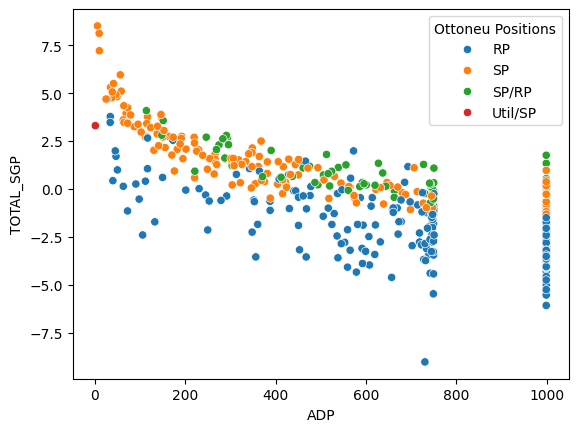

In [94]:
sns.scatterplot(Pitcher_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions')

In [95]:
Pitcher_Projections_df['TOTAL_SGP_Rank'] = Pitcher_Projections_df['TOTAL_SGP'].rank(ascending=False)
Hitter_Projections_df['TOTAL_SGP_Rank'] = Hitter_Projections_df['TOTAL_SGP'].rank(ascending=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

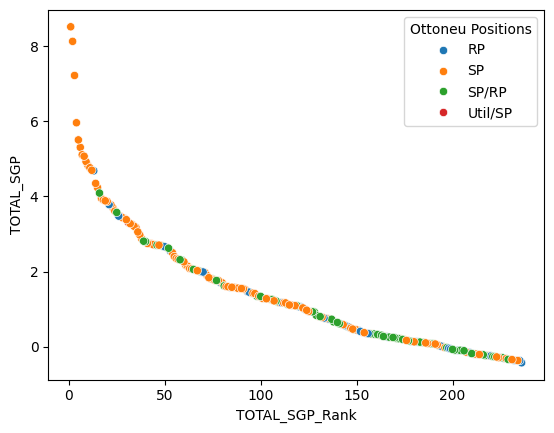

In [96]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']*1.1],x='TOTAL_SGP_Rank',y='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

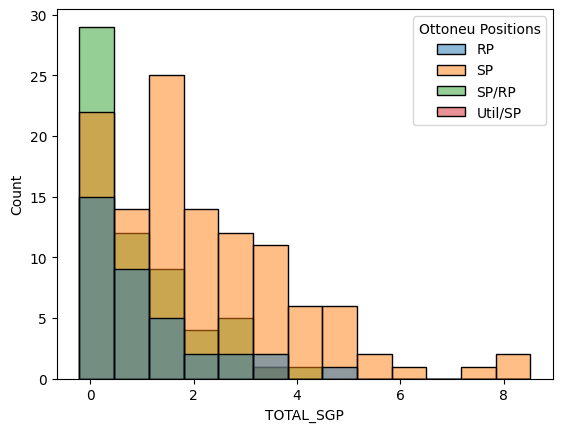

In [97]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']],x='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

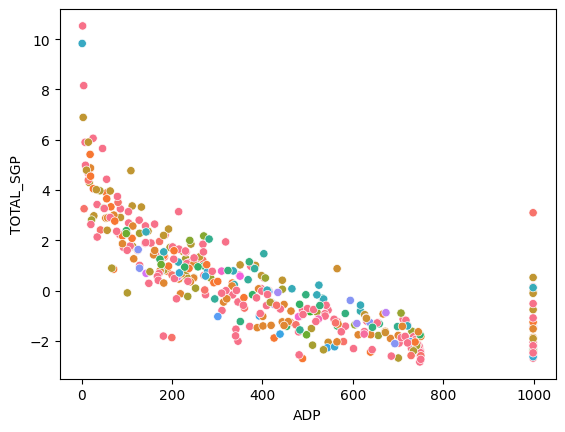

In [98]:
sns.scatterplot(Hitter_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions',legend=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

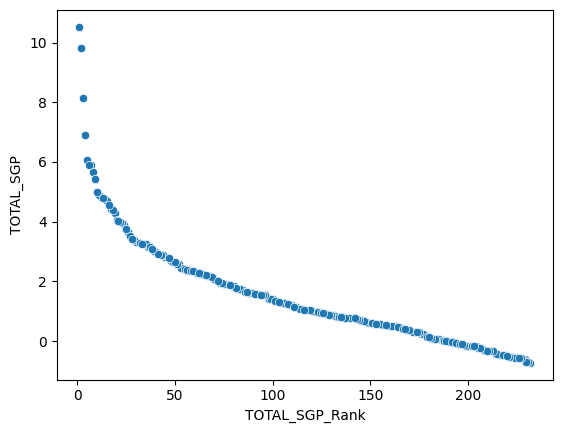

In [99]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Rank',y='TOTAL_SGP')

In [100]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.]['TOTAL_SGP'].count()/Num_teams

np.float64(15.666666666666666)

In [101]:
Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)].groupby('Ottoneu Positions')['TOTAL_SGP'].count()/Num_teams

Ottoneu Positions
RP         2.416667
SP         9.333333
SP/RP      4.416667
Util/SP    0.083333
Name: TOTAL_SGP, dtype: float64

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

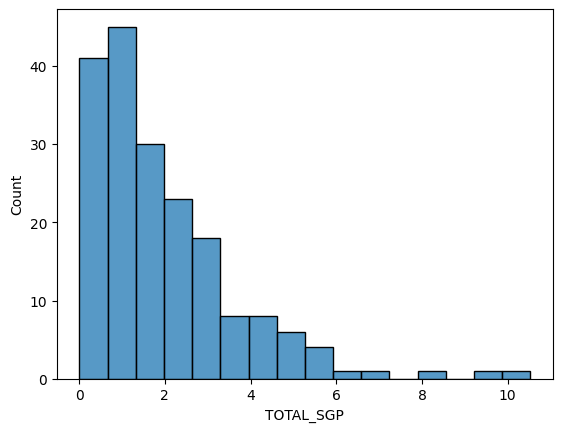

In [102]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.],x='TOTAL_SGP')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

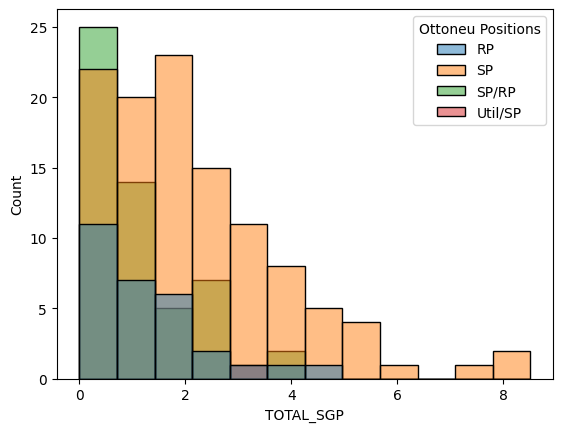

In [103]:
sns.histplot(Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)],x='TOTAL_SGP',hue='Ottoneu Positions')

In [104]:
# Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum()

In [105]:
Val_per_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [106]:
Val_per_SGP_Hitter

np.float64(7.173690598891575)

In [107]:
Hitter_Projections_df['TOTAL_SGP_Val'] = Hitter_Projections_df['TOTAL_SGP']*Val_per_SGP_Hitter

In [108]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].count()

np.int64(232)

In [109]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(220.46191144955012)

In [116]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.].groupby(['Repl_Pos'])[['Ottoneu Positions']].count()

,Ottoneu Positions
Repl_Pos,
1B,19
2B,13
3B,13
C,21
OF,71
SS,40
Util,2


In [114]:
Replacement_Level

{'C': 24,
 '1B': 25,
 '2B': 27,
 'SS': 44,
 '3B': 19,
 'OF': 89,
 'Util': 233,
 'SP': 150,
 'RP': 65,
 'P': 215}

In [118]:
for stat in Scoring_Categories_Batting:
    Val_per_stat_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']][f'{stat}_SGP_norm'].sum())
    Hitter_Projections_df[f'{stat}_SGP_Val'] = Hitter_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Hitter
    print(stat, Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.][f'{stat}_SGP_Val'].sum()/Num_teams)

R 235.1993339883326
HR 221.88645153428448
OBP 203.68530156391043
SLG 209.4544667994572


<Axes: xlabel='TOTAL_SGP_Val', ylabel='Count'>

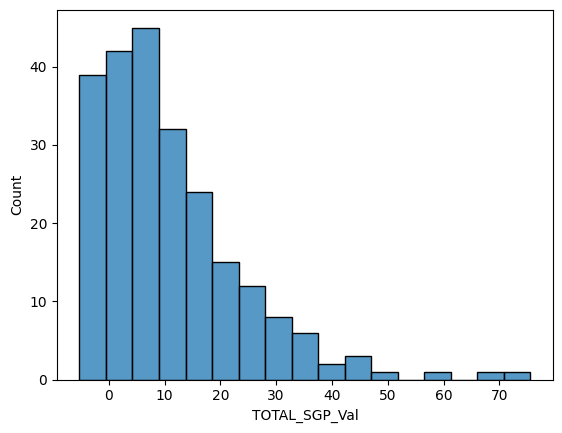

In [119]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val')

In [120]:
print(f'Pct bias Hitting: {(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum() - Hitter_budget)/Hitter_budget*100:.2f}%')

Pct bias Hitting: 3.99%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

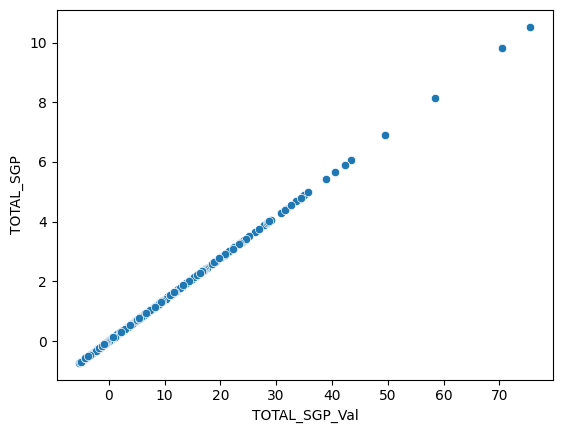

In [121]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [122]:
# Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].sum()

In [123]:
Val_per_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [124]:
Pitcher_Projections_df['TOTAL_SGP_Val'] = Pitcher_Projections_df['TOTAL_SGP']*Val_per_SGP_Pitcher

In [125]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].count()

np.int64(214)

In [126]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP'].count()

np.int64(177)

In [127]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(191.22727866511494)

In [128]:
for stat in Scoring_Categories_Pitching:
    Val_per_stat_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']][f'{stat}_SGP_norm'].sum())
    Pitcher_Projections_df[f'{stat}_SGP_Val'] = Pitcher_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Pitcher
    print(stat, Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.][f'{stat}_SGP_Val'].sum()/Num_teams)

SO 194.28233679355108
HR9 184.4467744310579
ERA 179.87126531197353
WHIP 181.9316769973669


In [129]:
print(f'Pct bias Pitching: {(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.]['TOTAL_SGP_Val'].sum() - Pitcher_budget)/Pitcher_budget*100:.2f}%')

Pct bias Pitching: 1.72%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

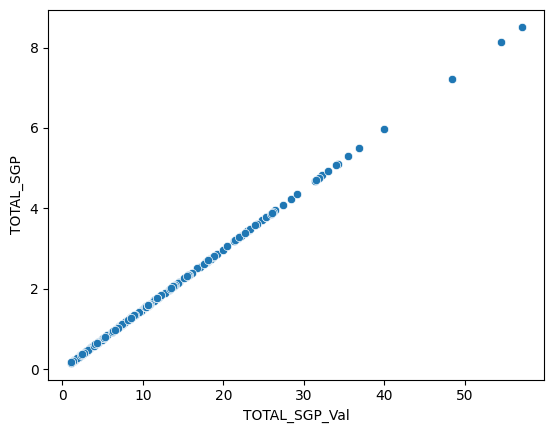

In [130]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [131]:
Pitcher_Projections_df[Player_id_cols+['IP','SO','HR9','ERA','WHIP','SO_SGP_Val','HR9_SGP_Val','ERA_SGP_Val','WHIP_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,NameASCII,Team,Ottoneu Positions,IP,SO,HR9,ERA,WHIP,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
344,22267,35204,Tarik Skubal,Tarik Skubal,DET,SP,198.89880,239.87600,0.882934,2.687728,0.987149,41.352536,86.412592,64.728277,74.505126,8.517067,57.055224
714,33677,43894,Paul Skenes,Paul Skenes,PIT,SP,193.44560,231.92120,0.790954,2.767541,1.051617,39.277597,108.376949,60.144796,58.225739,8.128757,54.453963
521,27463,38312,Garrett Crochet,Garrett Crochet,BOS,SP,190.40240,232.46840,0.904065,3.008174,1.074135,39.420329,78.077230,49.859622,52.483866,7.220492,48.369562
146,17995,21015,Logan Webb,Logan Webb,SFG,SP,201.10720,193.48320,0.765265,3.392781,1.189805,29.251384,118.752398,35.848790,27.328811,5.962100,39.939678
655,30279,41042,Bryan Woo,Bryan Woo,SEA,SP,193.10920,200.26880,1.150858,3.224773,1.046878,31.021347,15.067817,41.659296,59.228852,5.505008,36.877655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,17556,23830,Jimmy Herget,Jimmy Herget,COL,RP,79.68184,73.30852,1.395411,4.645474,1.355101,2.423327,-175.848939,-63.793213,-41.557985,-5.478433,-36.699632
697,31967,42728,Drew Thorpe,Drew Thorpe,CHW,RP,69.27496,52.69152,1.377500,4.723535,1.363868,-2.954435,-156.343610,-62.446243,-40.428562,-5.540863,-37.117847
668,31552,42643,Zach Agnos,Zach Agnos,COL,RP,48.61224,40.41948,1.437977,5.127168,1.472559,-6.155489,-144.218413,-65.292654,-55.278230,-6.084572,-40.760112
317,21649,33485,Luis Medina,Luis Medina,ATH,RP,109.99320,95.63456,1.194518,4.768603,1.451077,8.246878,-113.471270,-87.808493,-93.078462,-6.094569,-40.827080


<Axes: xlabel='TOTAL_SGP_Val', ylabel='SO_SGP_Val'>

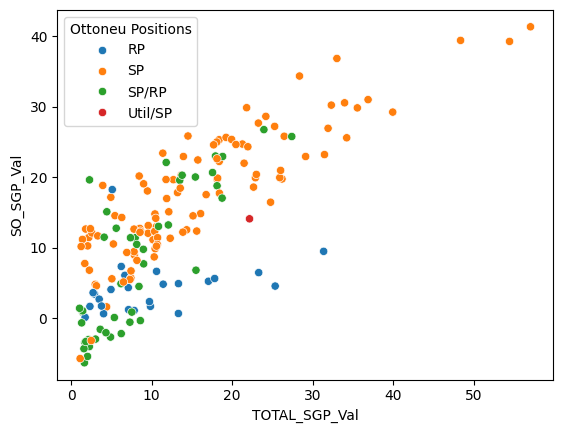

In [132]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='SO_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='HR9_SGP_Val'>

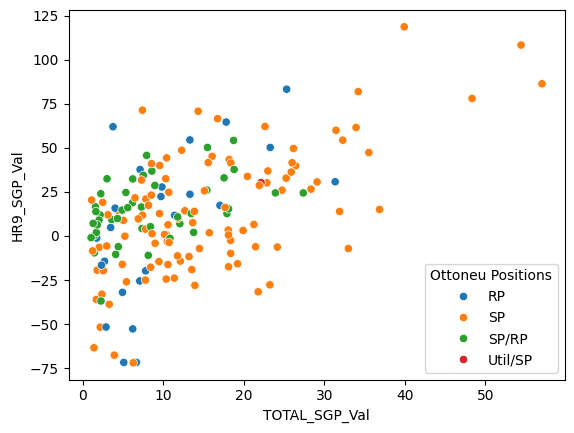

In [133]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='HR9_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='ERA_SGP_Val'>

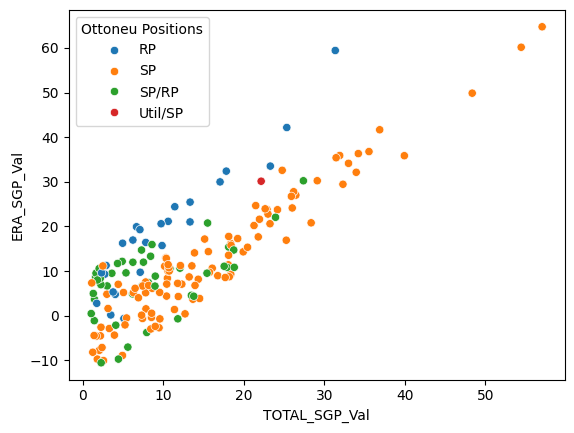

In [134]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='ERA_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='WHIP_SGP_Val'>

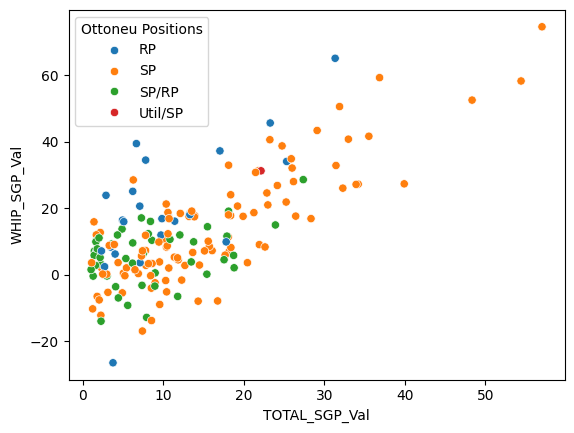

In [135]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 1.],x='TOTAL_SGP_Val',y='WHIP_SGP_Val',hue='Ottoneu Positions')

In [136]:
Hitter_Projections_df[Player_id_cols+['G','R','HR','OBP','SLG','R_SGP_Val','HR_SGP_Val','OBP_SGP_Val','SLG_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,NameASCII,Team,Ottoneu Positions,G,R,HR,OBP,SLG,R_SGP_Val,HR_SGP_Val,OBP_SGP_Val,SLG_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
52,15640,18312,Aaron Judge,Aaron Judge,NYY,OF,153.025200,109.910000,51.318920,0.422946,0.636914,47.414465,69.622849,117.211633,93.559604,10.528447,75.527821
150,19755,33600,Shohei Ohtani,Shohei Ohtani,LAD,Util/SP,154.564800,118.400000,48.565160,0.384457,0.609322,61.349731,66.504894,76.454055,86.453737,9.830690,70.522327
178,20123,23717,Juan Soto,Juan Soto,NYM,OF,157.975200,107.358800,38.839080,0.411102,0.545443,45.055268,45.914020,107.413147,58.564082,8.153503,58.490704
335,25764,36668,Bobby Witt Jr.,Bobby Witt Jr.,KCR,SS,156.003600,105.326000,30.450600,0.356083,0.530721,53.374534,41.264073,45.258319,60.451037,6.890032,49.426961
63,16478,18347,Kyle Schwarber,Kyle Schwarber,PHI,OF,155.792571,97.540571,42.414686,0.352581,0.499404,35.975957,52.706849,42.635477,40.487658,6.060220,43.474141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,18373,22670,Ryan Mountcastle,Ryan Mountcastle,BAL,1B,36.729840,17.536840,5.215076,0.306171,0.418532,-44.879029,-21.665673,0.151122,7.524689,-2.700624,-19.373440
494,31490,42347,Wade Meckler,Wade Meckler,LAA,OF,27.613520,11.672320,1.118032,0.314629,0.323531,-43.429870,-25.747307,11.129755,1.551748,-2.731535,-19.595184
196,20538,32585,Jose Miranda,Jose Miranda,SDP,3B,32.983480,14.705880,3.242444,0.296458,0.368454,-41.899669,-22.148077,-0.470623,1.808460,-2.766606,-19.846773
81,17620,22922,Myles Straw,Myles Straw,TOR,OF,33.297560,14.242800,1.083944,0.296912,0.317377,-41.052844,-25.812066,6.855810,-0.329494,-2.784699,-19.976570


In [137]:
import os, errno
# Create the directory and parent directories if they do not exist
os.makedirs(League_path+'/SGP_Val_'+SGP_Calc_date, exist_ok=True)
Hitter_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Hitter_Projections_df.csv'
Pitcher_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Pitcher_Projections_df.csv'
Hitter_Projections_df.to_csv(Hitter_csv_path,index=False)
Pitcher_Projections_df.to_csv(Pitcher_csv_path,index=False)

In [138]:
def symlink_force(target, link_name):
    try:
        os.symlink(target, link_name)
    except OSError as e:
        if e.errno == errno.EEXIST:
            os.remove(link_name)
            os.symlink(target, link_name)
        else:
            raise e

In [139]:
if publish_Val_Update['Hitter']:
    Hitter_latest_link_name = League_path+'/Latest_Hitter_Proj.csv'
    symlink_force(Hitter_csv_path,Hitter_latest_link_name)

if publish_Val_Update['Pitcher']:
    Pitcher_latest_link_name = League_path+'/Latest_Pitcher_Proj.csv'
    symlink_force(Pitcher_csv_path,Pitcher_latest_link_name)